# Import the Packages needed for coding

In [28]:
# first import packages 
import pandas as pd
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline 
import geopandas as gpd


# Read in the data & Clean it up!

In [29]:
#Read in my data 
pm25 = pd.read_csv("pm2.5.csv")
asthma = pd.read_csv("asthma.csv")


# PM2.5 data!

In [30]:
#explore the columns of the pm2.5 data 
pm25.head()

,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Annual mean mcg/m3,Summer mean mcg/m3,Winter mean mcg/m3
0,2023,Citywide,1,0,-,-,New York City,New York City,6.7,8.8,6.1
1,2023,Borough,3,1,3,Manhattan,Manhattan,Manhattan,7.3,9.3,7.2
2,2023,Borough,1,1,1,Bronx,Bronx,Bronx,6.9,9.3,6.6
3,2023,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,6.7,8.8,6.3
4,2023,Borough,4,1,4,Queens,Queens,Queens,6.6,8.8,6.1


In [31]:
#PM25 remove the columns i don't need and retain the ones i do!
pm25_new = pm25[[
    "TimePeriod",
    "Borough",
    "Annual mean mcg/m3",
    "Summer mean mcg/m3",
    "Winter mean mcg/m3"
]]
pm25_new.head()

,TimePeriod,Borough,Annual mean mcg/m3,Summer mean mcg/m3,Winter mean mcg/m3
0,2023,-,6.7,8.8,6.1
1,2023,Manhattan,7.3,9.3,7.2
2,2023,Bronx,6.9,9.3,6.6
3,2023,Brooklyn,6.7,8.8,6.3
4,2023,Queens,6.6,8.8,6.1


In [32]:
#rename the columns for ease in coding!
pm25_new = pm25_new.rename(columns={
    "TimePeriod": "year",
    "Annual mean mcg/m3": "annual_pm25",
    "Summer mean mcg/m3": "summer_pm25",
    "Winter mean mcg/m3": "winter_pm25"
})
pm25_new.head()

,year,Borough,annual_pm25,summer_pm25,winter_pm25
0,2023,-,6.7,8.8,6.1
1,2023,Manhattan,7.3,9.3,7.2
2,2023,Bronx,6.9,9.3,6.6
3,2023,Brooklyn,6.7,8.8,6.3
4,2023,Queens,6.6,8.8,6.1


# Asthma data!

In [33]:
#explore the columns of the asthma data 
asthma.head()

,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Number,"Estimated annual rate per 10,000"
0,2023,Citywide,1,0,-,-,New York City,New York City,"2,558",21.8
1,2023,Borough,1,1,1,Bronx,Bronx,Bronx,986,41.6
2,2023,Borough,3,1,3,Manhattan,Manhattan,Manhattan,391,25.5
3,2023,Borough,4,1,4,Queens,Queens,Queens,492,15.8
4,2023,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,619,15.7


In [34]:
#Asthma remove the columns i don't need and retain the ones i do!
asthma_new = asthma[[
    "TimePeriod",
    "Borough",
    "Number",
    "Estimated annual rate per 10,000",
]]
asthma_new.head()

,TimePeriod,Borough,Number,"Estimated annual rate per 10,000"
0,2023,-,"2,558",21.8
1,2023,Bronx,986,41.6
2,2023,Manhattan,391,25.5
3,2023,Queens,492,15.8
4,2023,Brooklyn,619,15.7


In [35]:
#rename the columns for ease in coding!
asthma_new = asthma_new.rename(columns={
    "TimePeriod": "year",
    "Number": "asthma",
    "Estimated annual rate per 10,000": "asthma_rate"
})
asthma_new.head()

,year,Borough,asthma,asthma_rate
0,2023,-,"2,558",21.8
1,2023,Bronx,986,41.6
2,2023,Manhattan,391,25.5
3,2023,Queens,492,15.8
4,2023,Brooklyn,619,15.7


# Merge the data across 5 Boroughs and Years (2009-2023)

In [36]:
# Merge on year + borough in order to plot the variables and test the relationship!
df = pd.merge(pm25_new, asthma_new, on=["year", "Borough"])
# i noticed that NYC as an average was in the borough data as a - so lets replace it 
df["Borough"] = df["Borough"].replace("-", "NYC")
print(df.head())

   year    Borough  annual_pm25  summer_pm25  winter_pm25 asthma  asthma_rate
0  2023        NYC          6.7          8.8          6.1  2,558         21.8
1  2023  Manhattan          7.3          9.3          7.2    391         25.5
2  2023      Bronx          6.9          9.3          6.6    986         41.6
3  2023   Brooklyn          6.7          8.8          6.3    619         15.7
4  2023     Queens          6.6          8.8          6.1    492         15.8


# Start to Plot (Scatter plot, time series, Map, and Multi-Panel!)

## Scatter plots

### PM2.5 vs Pediatric Asthma in NYC

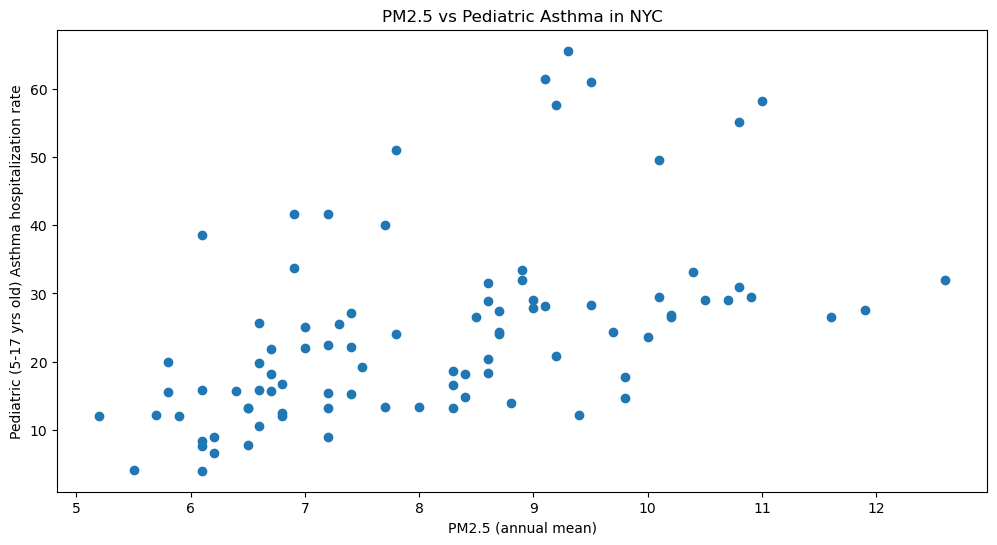

In [37]:
#first make a scatter plot of annual pm2.5 and asthma rate since its standaridized!
plt.scatter(df["annual_pm25"], df["asthma_rate"])

plt.xlabel("PM2.5 (annual mean)")
plt.ylabel("Pediatric (5-17 yrs old) Asthma hospitalization rate")
plt.title("PM2.5 vs Pediatric Asthma in NYC")
plt.show()

#notes on the relationship based on what I see visually is a highly positive correlation between asthma and pm2.5, 
#I see many high data pts as well ranging from 40-50 rates and with higher pm2.5 values possibly signifiyig certain "Asthma Alleys"
# I found a PM2.5 scale for air quality from the EPA that essentially signifies (5-1 2mcg/m3 as "good" air quality), so while NYC 
#has relatively clean AQ its 
#https://www.epa.gov/sites/default/files/2016-04/documents/2012_aqi_factsheet.pdf
# https://www.deq.nc.gov/about/divisions/air-quality/air-quality-planning/attainment/2024-pm25-annual-standard#:~:text=AQI%20Category%20and%20Index%20Value,9.1%20to


### PM2.5 vs Pediatric Asthma in NYC by Borough

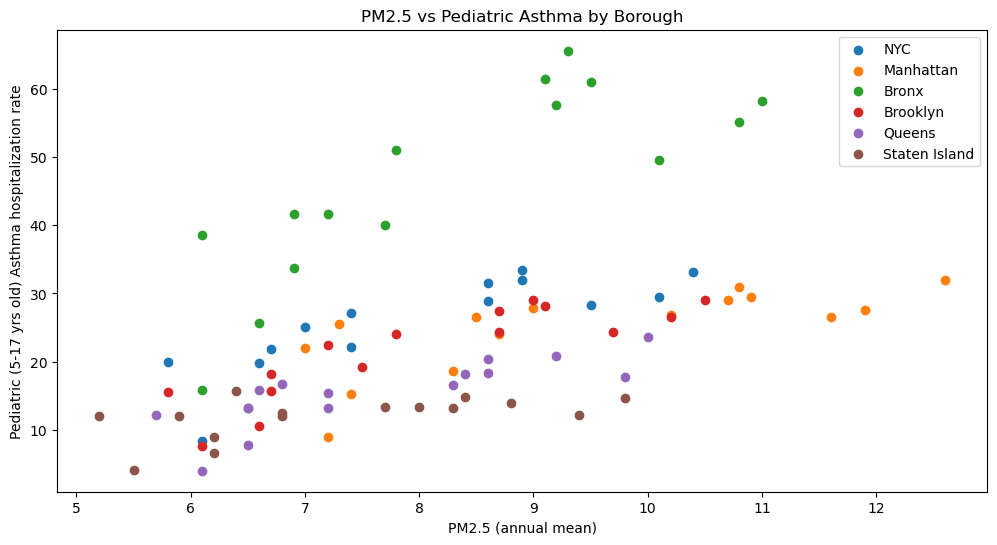

In [39]:
#I found it hard to interpert the data and thought it would be more appropriate to color the pts based on the boroughs they represent!
#single out the column and makes a list of its content like this ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
boroughs = df["Borough"].unique()

#make a for loop for each borough at a time slicing the data for asthma and pm2.5
for b in boroughs:
    subset = df[df["Borough"] == b] 
    plt.scatter(subset["annual_pm25"], subset["asthma_rate"], label=b) #can turn this into a line plot by just switching out the plt.scatter with plt.plot

plt.xlabel("PM2.5 (annual mean)")
plt.ylabel("Pediatric (5-17 yrs old) Asthma hospitalization rate")
plt.title("PM2.5 vs Pediatric Asthma by Borough")
plt.legend()
plt.show()

### PM2.5 Summer Average vs Pediatric Asthma in NYC by Borough

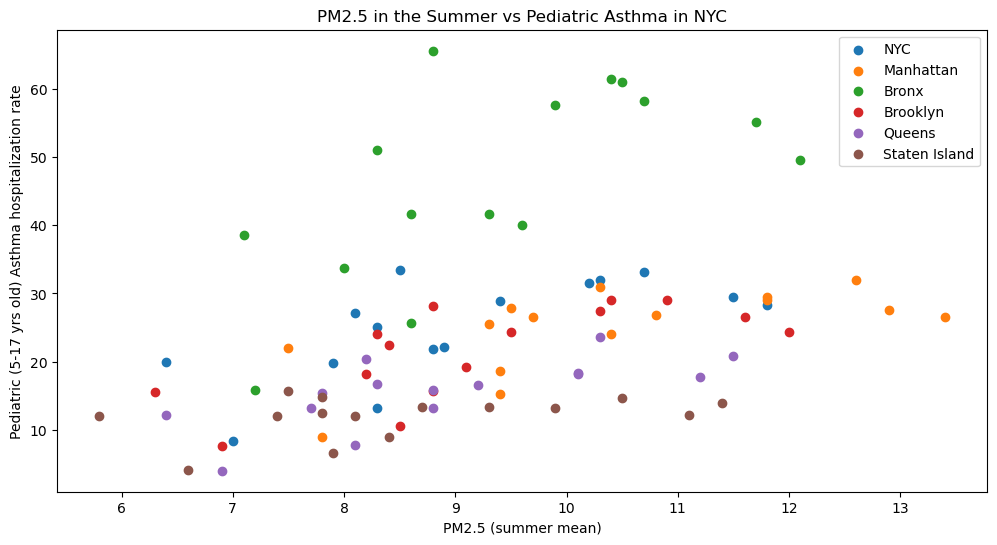

In [40]:
#did the same for summer PM2.5
for b in boroughs:
    subset = df[df["Borough"] == b] 
    plt.scatter(subset["summer_pm25"], subset["asthma_rate"], label=b)
    
plt.xlabel("PM2.5 (summer mean)")
plt.ylabel("Pediatric (5-17 yrs old) Asthma hospitalization rate")
plt.title("PM2.5 in the Summer vs Pediatric Asthma in NYC")
plt.legend()
plt.show()

### PM2.5 Winter Average vs Pediatric Asthma in NYC by Borough

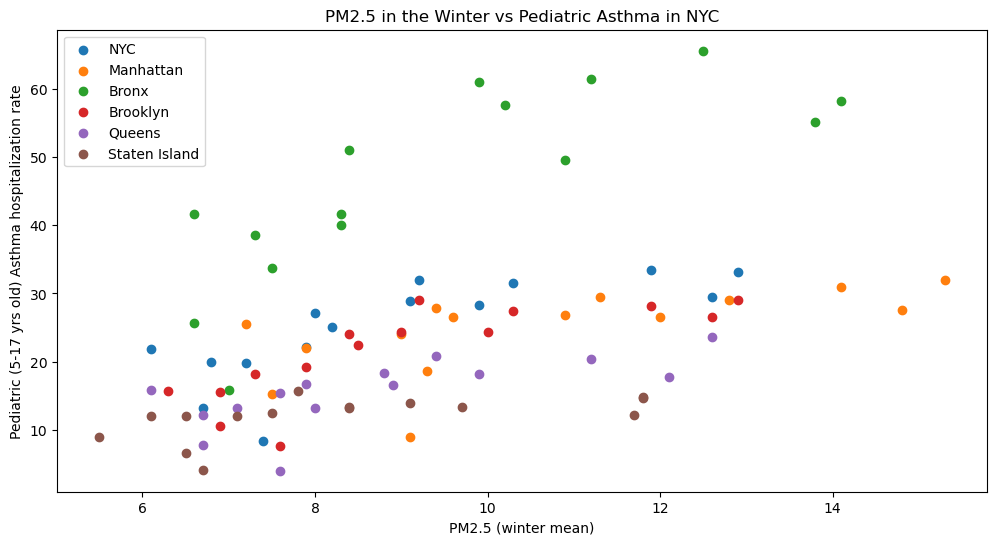

In [57]:
for b in boroughs:
    subset = df[df["Borough"] == b] 
    plt.scatter(subset["winter_pm25"], subset["asthma_rate"], label=b)
    
plt.xlabel("PM2.5 (winter mean)")
plt.ylabel("Pediatric (5-17 yrs old) Asthma hospitalization rate")
plt.title("PM2.5 in the Winter vs Pediatric Asthma in NYC")
plt.legend()
plt.show()

## Time-series

### Time series of PM2.5 annual average over time

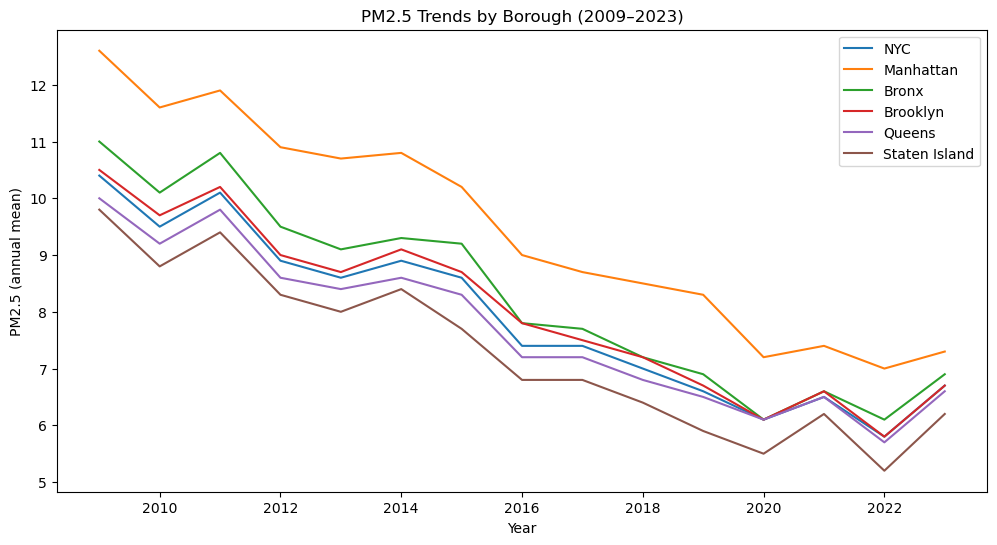

In [58]:
#Plot a time series using our prev for loop by borough again, this time seeing PM2.5 annually across 15 years!

for b in df["Borough"].unique():
    subset = df[df["Borough"] == b]
    plt.plot(subset["year"], subset["annual_pm25"], label=b)

plt.xlabel("Year")
plt.ylabel("PM2.5 (annual mean)")
plt.title("PM2.5 Trends by Borough (2009–2023)")
plt.legend()
plt.show()

### Time series of Pediatric (5-17 yrs old) Asthma over time

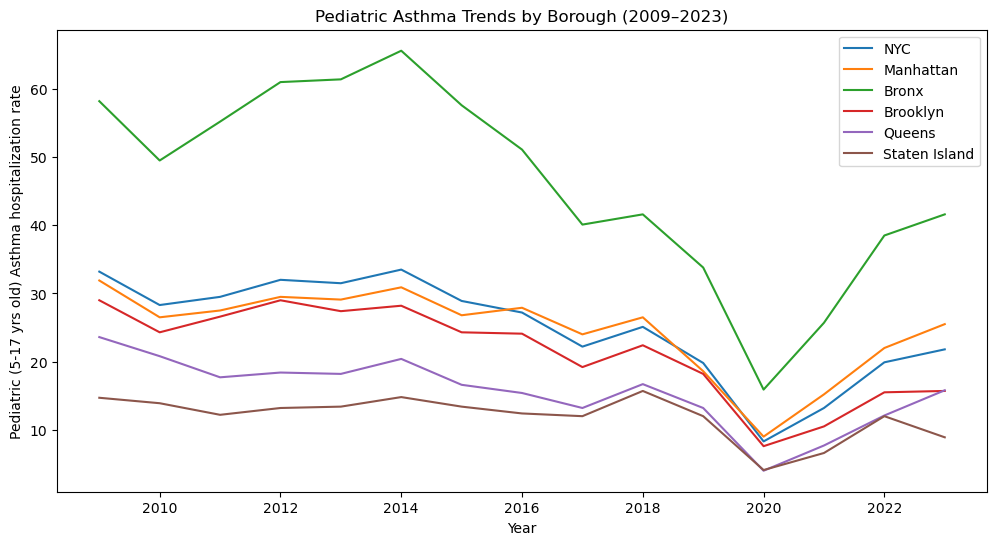

In [59]:
#now do the same but for Pediatric (5-17 yrs old) Asthma over time!
for b in df["Borough"].unique():
    subset = df[df["Borough"] == b]
    plt.plot(subset["year"], subset["asthma_rate"], label=b)

plt.xlabel("Year")
plt.ylabel("Pediatric (5-17 yrs old) Asthma hospitalization rate")
plt.title("Pediatric Asthma Trends by Borough (2009–2023)")
plt.legend()
plt.show()

## Map it onto a shape file!

<Axes: >

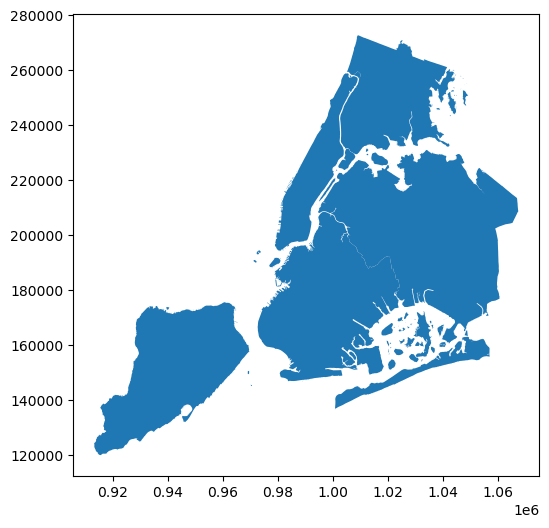

In [66]:
#Downloaded the shape file from https://www.nyc.gov/content/planning/pages/resources/datasets/borough-boundaries
#Also downloaded the geopandas package then read the file in!
nyc_map = gpd.read_file("nybb.shp")
nyc_map
nyc_map.plot()

In [69]:
#also chekc the column names so that i can merge my data frame with the map 
# I found BoroName
nyc_map.columns
#check what is inside of boroname 
nyc_map["BoroName"]

0    Staten Island
1            Bronx
2           Queens
3        Manhattan
4         Brooklyn
Name: BoroName, dtype: object

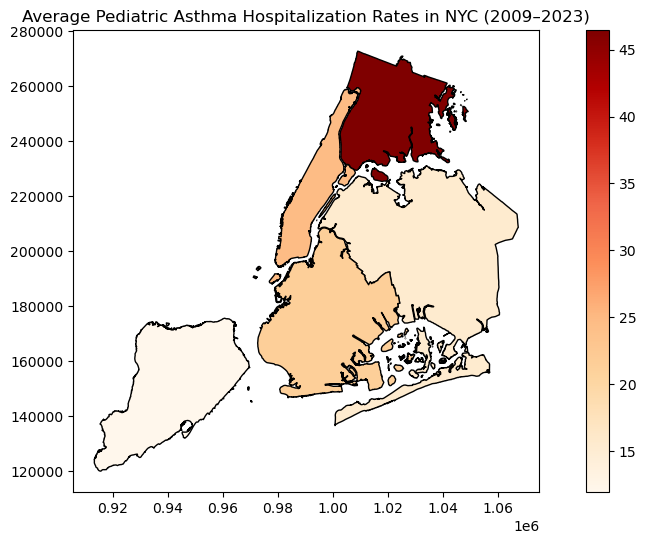

In [125]:
#first remove NYC average from the boroughs in our og data set so that the map doesnt crash out!
df_no_nyc = df[df["Borough"] != "NYC"]

#now we merge boruoguhs asthma rates with pm2.5 ps the average is over the 15 yr period
df_map_data = df_no_nyc.groupby("Borough")[["annual_pm25", "asthma_rate"]].mean().reset_index()
#now we merge the shape file with our data!
map_df = nyc_map.merge(df_map_data, left_on="BoroName", right_on="Borough")

#now plot asthma rates across average of 15 years
map_df.plot(column="asthma_rate", cmap= "OrRd", edgecolor="black", linewidth=1, legend=True)
plt.title("Average Pediatric Asthma Hospitalization Rates in NYC (2009–2023)")
plt.show()

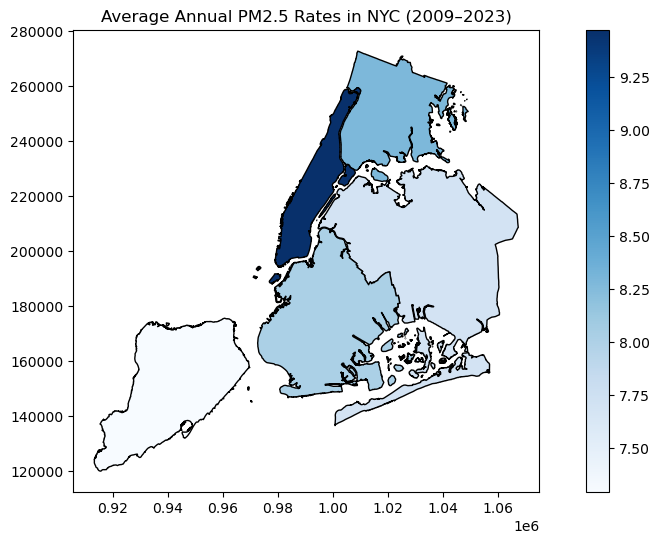

In [124]:
map_df.plot(column="annual_pm25", cmap= "Blues", edgecolor="black", linewidth=1, legend=True)
plt.title("Average Annual PM2.5 Rates in NYC (2009–2023)")
plt.show()


## Multi-Panel 2009 vs 2023

(905464.7390380859, 1075092.8783935546, 112492.57380371094, 280480.09001464845)

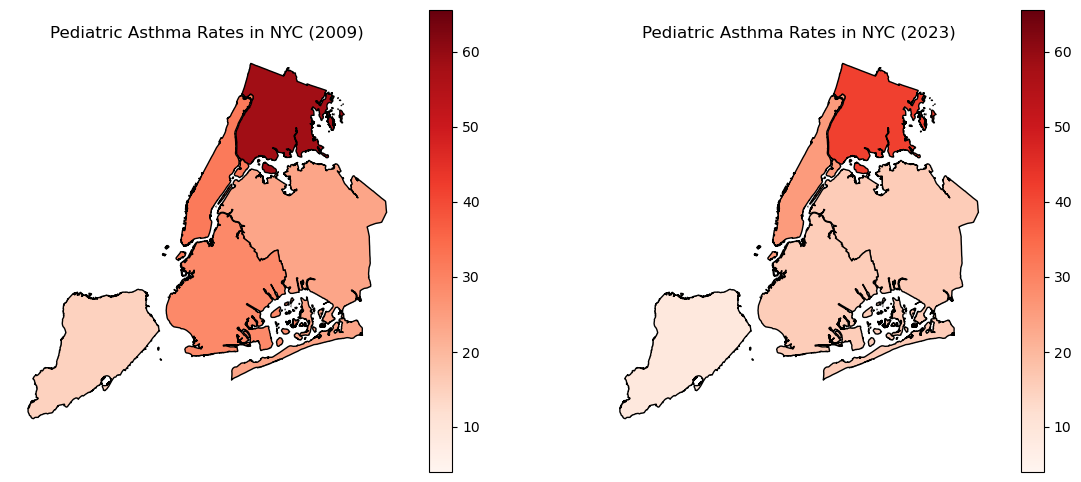

In [123]:
#first filter our no nyc data by each of the two years to isolate them on the map!
df_2009 = df_no_nyc[df_no_nyc["year"] == 2009]
df_2023 = df_no_nyc[df_no_nyc["year"] == 2023]

#then merge into the shape file 
map_2009 = nyc_map.merge(df_2009, left_on="BoroName", right_on="Borough")
map_2023 = nyc_map.merge(df_2023, left_on="BoroName", right_on="Borough")

#now create a color scale so that both have the same scales 
vmin = df_no_nyc["asthma_rate"].min()
vmax = df_no_nyc["asthma_rate"].max()

#create a multipanel figure to put the plots into 1 row 2 columns!
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# this is to plot 09's asthma rates
map_2009.plot(
    column="asthma_rate",
    cmap="Reds",
    linewidth=1,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[0]
)

#then give it a title & if i want turn off the axis lon and lat on the map so its easier to see!
axes[0].set_title("Pediatric Asthma Rates in NYC (2009)")
axes[0].axis("off")

#now do the same for 2023 just change the axes number 
map_2023.plot(column="asthma_rate",
    cmap="Reds",
    linewidth=1,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[1])

axes[1].set_title("Pediatric Asthma Rates in NYC (2023)")
axes[1].axis("off")

(905464.7390380859, 1075092.8783935546, 112492.57380371094, 280480.09001464845)

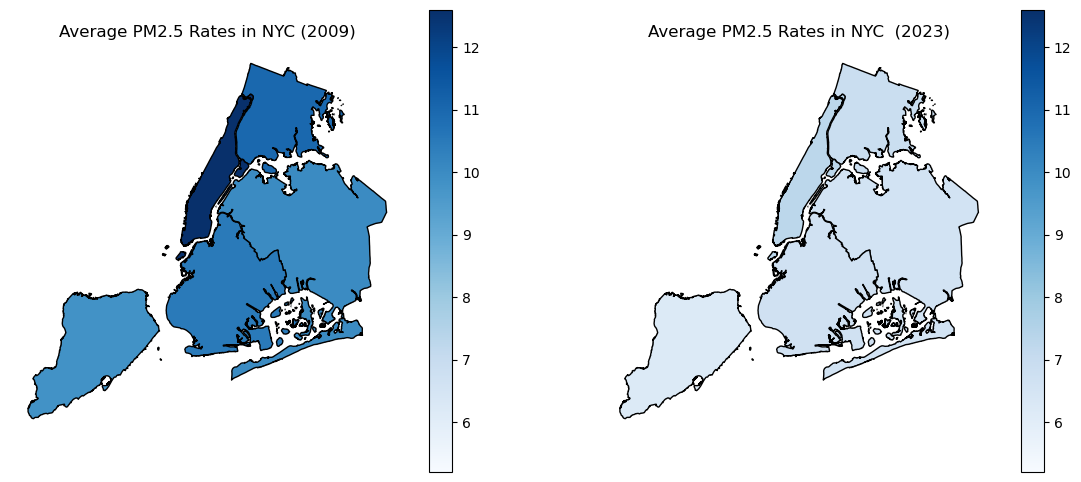

In [126]:

#now create a color scale so that both have the same scales 
vmin1 = df_no_nyc["annual_pm25"].min()
vmax1 = df_no_nyc["annual_pm25"].max()

#create a multipanel figure to put the plots into 1 row 2 columns!
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# this is to plot 09's asthma rates
map_2009.plot(
    column="annual_pm25",
    cmap="Blues",
    linewidth=1,
    edgecolor="black",
    legend=True,
    vmin=vmin1,
    vmax=vmax1,
    ax=axes[0]
)

#then give it a title & if i want turn off the axis lon and lat on the map so its easier to see!
axes[0].set_title("Average PM2.5 Rates in NYC (2009)")
axes[0].axis("off")

#now do the same for 2023 just change the axes number 
map_2023.plot(column="annual_pm25",
    cmap="Blues",
    linewidth=1,
    edgecolor="black",
    legend=True,
    vmin=vmin1,
    vmax=vmax1,
    ax=axes[1])

axes[1].set_title("Average PM2.5 Rates in NYC  (2023)")
axes[1].axis("off")

(905464.7390380859, 1075092.8783935546, 112492.57380371094, 280480.09001464845)

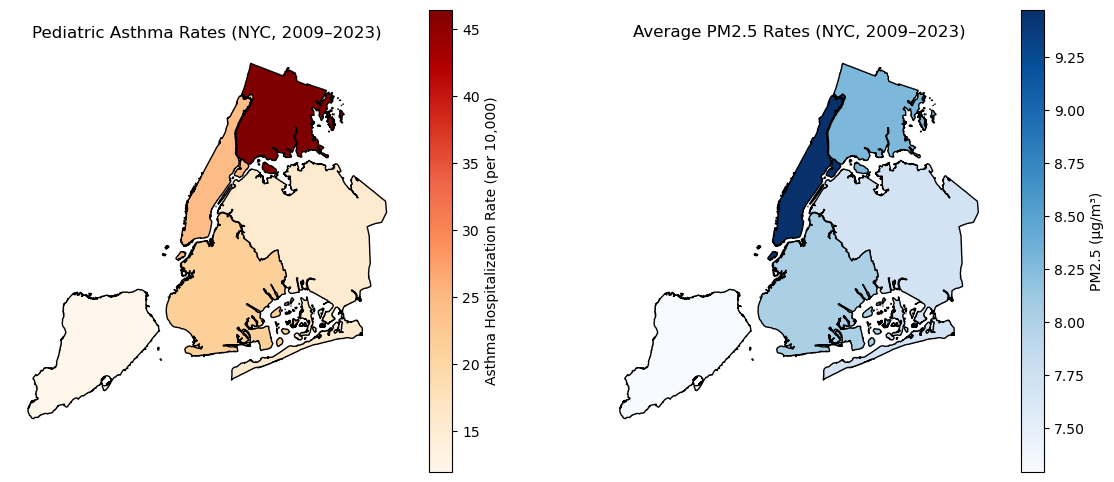

In [141]:
#make a multipanel fig with axes so 1 row with 2 columns!
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
#first remove NYC average from the boroughs in our og data set so that the map doesnt crash out!
df_no_nyc = df[df["Borough"] != "NYC"]

#now we merge boruoguhs asthma rates with pm2.5 ps the average is over the 15 yr period
df_map_data = df_no_nyc.groupby("Borough")[["annual_pm25", "asthma_rate"]].mean().reset_index()
#now we merge the shape file with our data!
map_df = nyc_map.merge(df_map_data, left_on="BoroName", right_on="Borough")

#now plot asthma rates across average of 15 years
map_df.plot(column="asthma_rate", 
            cmap= "OrRd", 
            edgecolor="black", 
            linewidth=1, 
            legend=True,
            legend_kwds={"label": "Asthma Hospitalization Rate (per 10,000)"},
            ax=axes[0])
axes[0].set_title("Pediatric Asthma Rates (NYC, 2009–2023)")
axes[0].axis("off")

map_df.plot(column="annual_pm25", 
            cmap= "Blues", 
            edgecolor="black", 
            linewidth=1, 
            legend=True,
            legend_kwds={"label": "PM2.5 (µg/m³)"},
            ax=axes[1])
axes[1].set_title("Average PM2.5 Rates (NYC, 2009–2023)")
axes[1].axis("off")
